<a href="https://colab.research.google.com/github/tehreem-zubair-S/DS-AI-Learning-Journey/blob/main/CANCER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LU

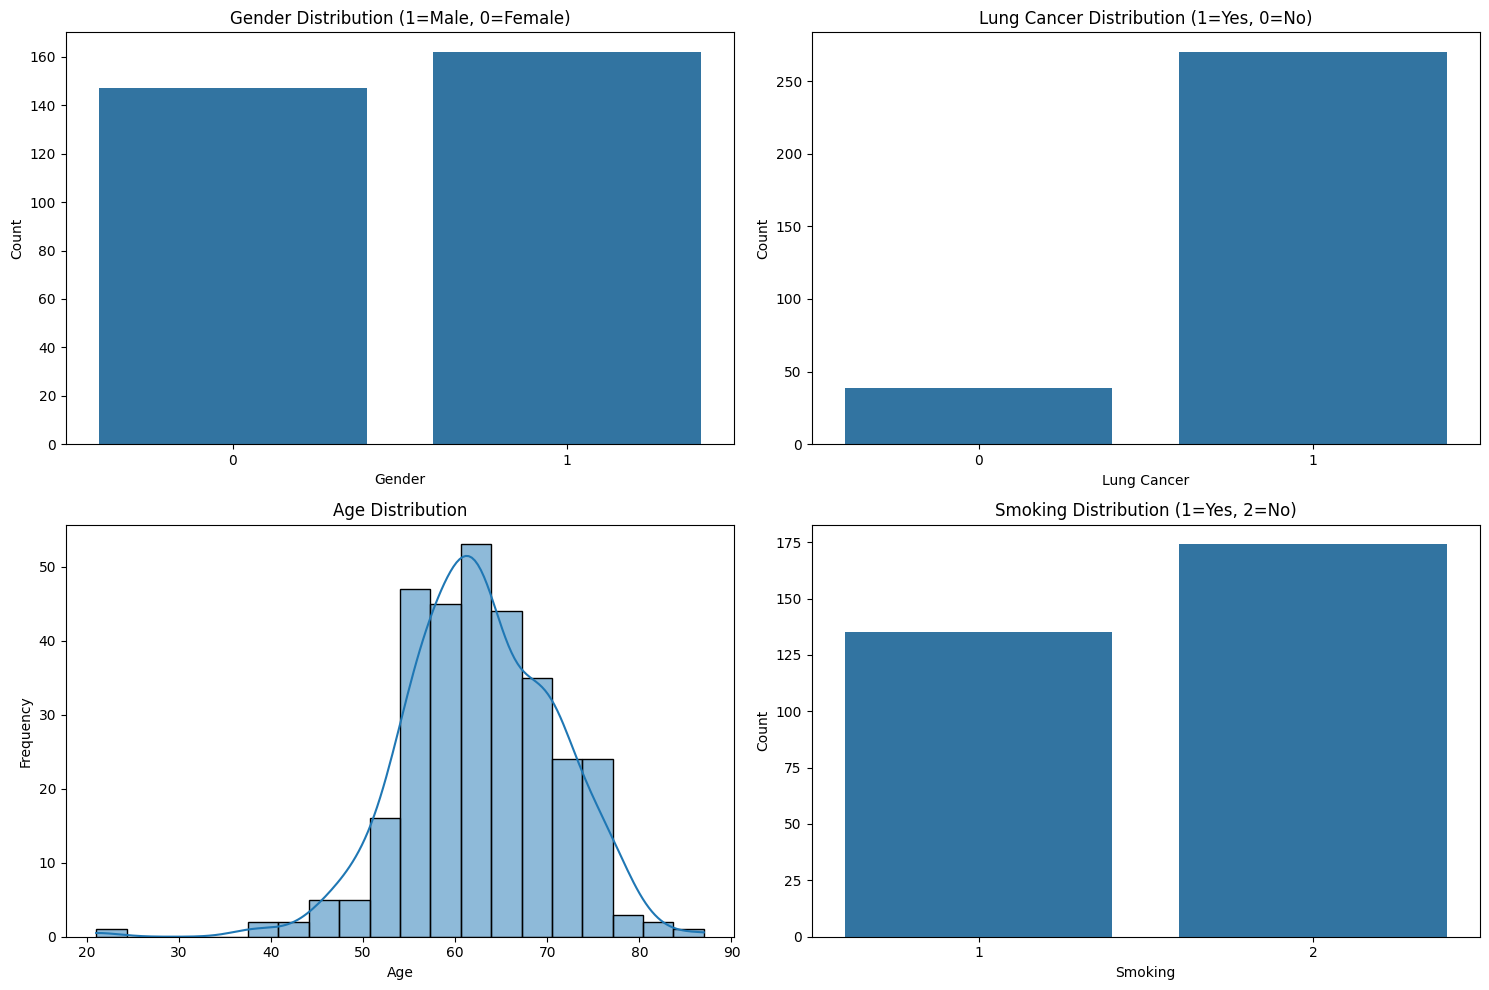


Variance Analysis:

Variance for numerical features:
AGE    67.409049
dtype: float64

Variance for categorical features (encoded as numbers):
GENDER                   0.250221
SMOKING                  0.246816
YELLOW_FINGERS           0.245955
ANXIETY                  0.250809
PEER_PRESSURE            0.250809
CHRONIC DISEASE          0.250788
FATIGUE                  0.220737
ALLERGY                  0.247594
WHEEZING                 0.247594
ALCOHOL CONSUMING        0.247594
COUGHING                 0.244505
SHORTNESS OF BREATH      0.230929
SWALLOWING DIFFICULTY    0.249863
CHEST PAIN               0.247594
dtype: float64


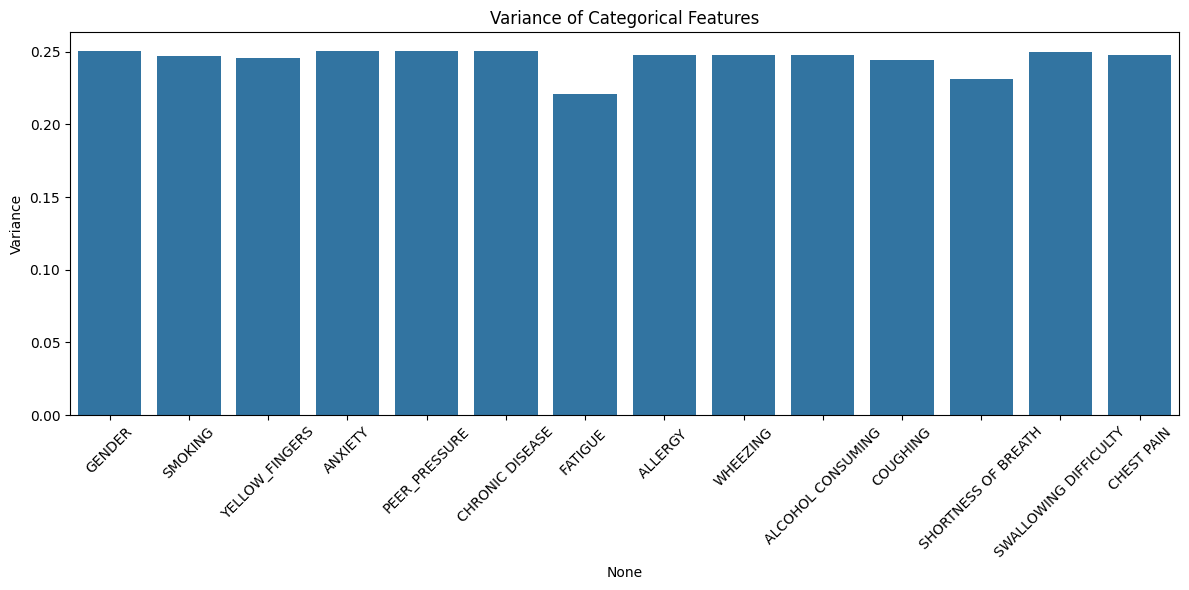


Model Evaluation:
Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.98      1.00      0.99        86

    accuracy                           0.98        93
   macro avg       0.99      0.86      0.91        93
weighted avg       0.98      0.98      0.98        93



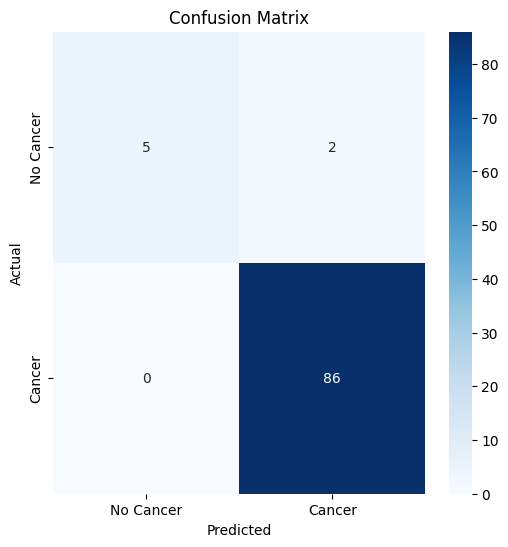

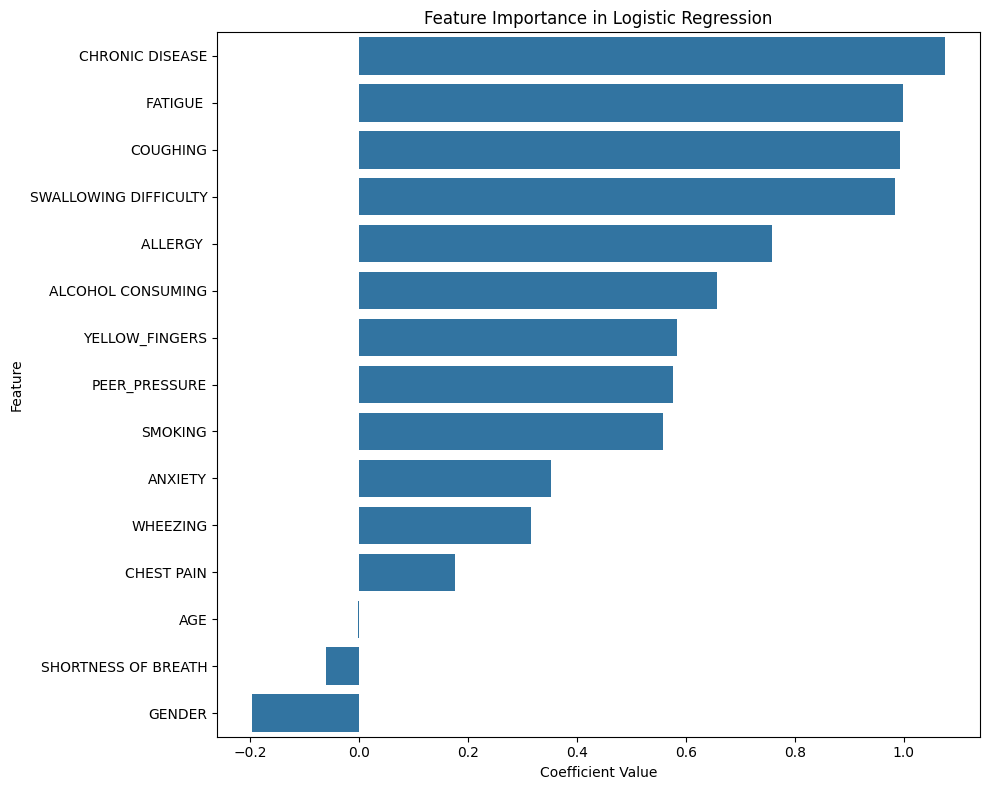

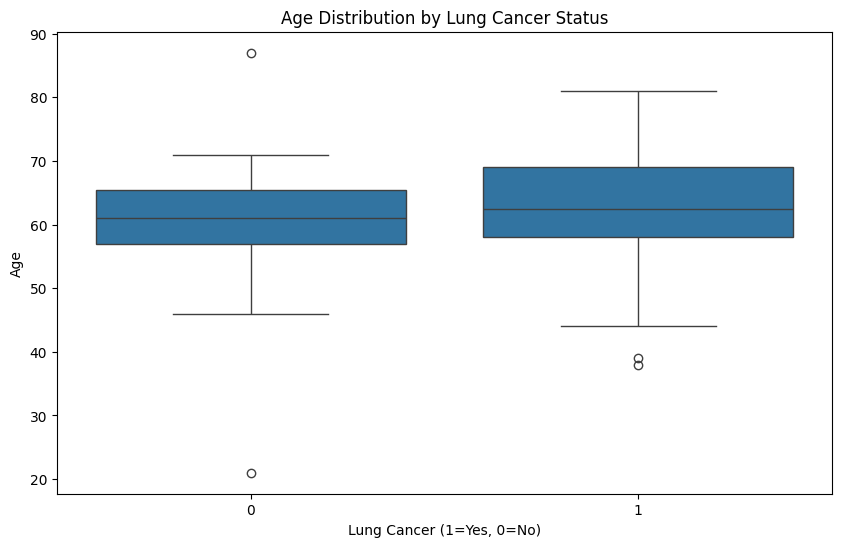

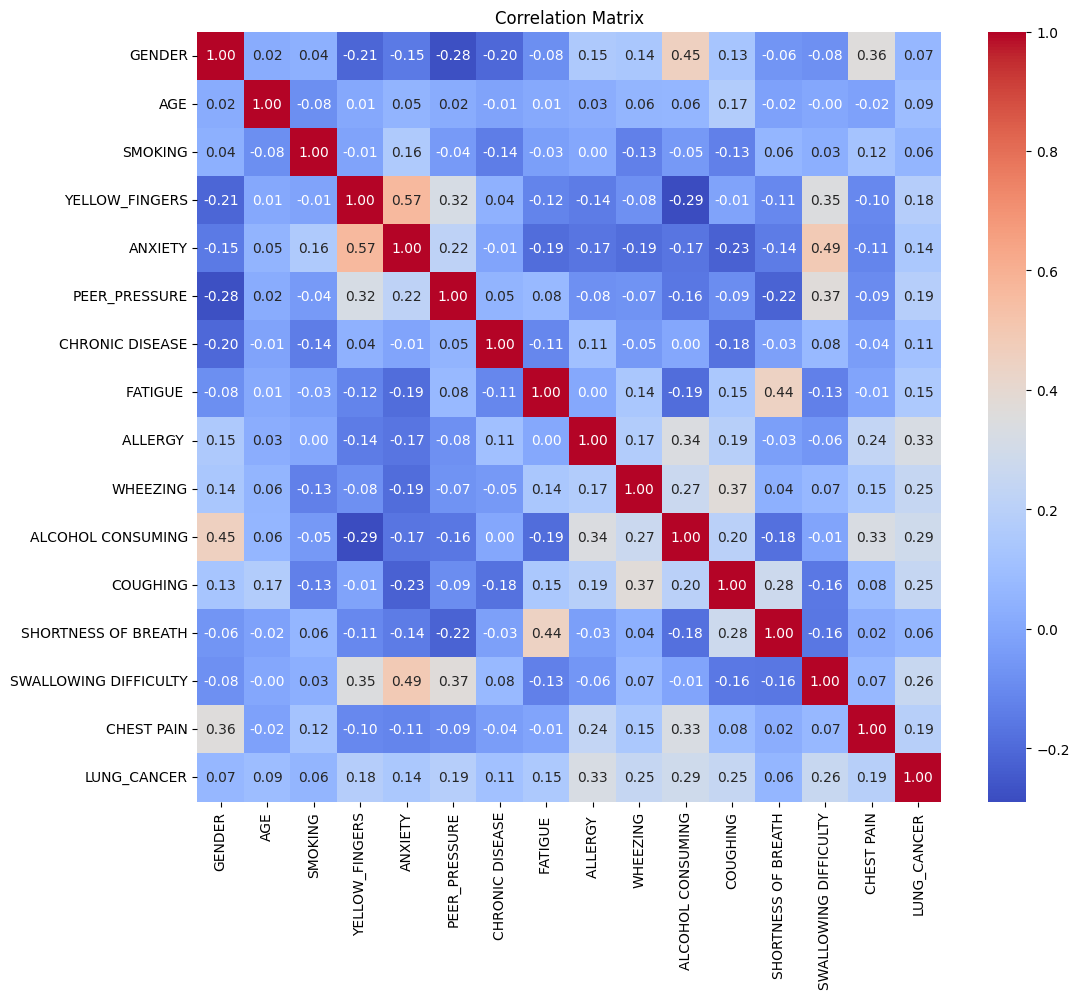

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# Load the dataset
url = "/content/archive.zip"  # Replace with your actual file path
# If running on Colab, you can upload the file directly:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('survey_lung_cancer.csv')

df = pd.read_csv(url)

# Display basic information
print("Dataset Information:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

# Data Preprocessing
# Convert categorical variables to numerical
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

# 1. Frequency Analysis
print("\nFrequency Analysis:")
# Gender distribution
gender_freq = df['GENDER'].value_counts()
print("\nGender Distribution:")
print(gender_freq)

# Lung cancer distribution
cancer_freq = df['LUNG_CANCER'].value_counts()
print("\nLung Cancer Distribution:")
print(cancer_freq)

# Age distribution
print("\nAge Distribution Statistics:")
print(df['AGE'].describe())

# Plot frequency distributions
plt.figure(figsize=(15, 10))

# Gender distribution
plt.subplot(2, 2, 1)
sns.countplot(x='GENDER', data=df)
plt.title('Gender Distribution (1=Male, 0=Female)')
plt.xlabel('Gender')
plt.ylabel('Count')

# Lung cancer distribution
plt.subplot(2, 2, 2)
sns.countplot(x='LUNG_CANCER', data=df)
plt.title('Lung Cancer Distribution (1=Yes, 0=No)')
plt.xlabel('Lung Cancer')
plt.ylabel('Count')

# Age distribution
plt.subplot(2, 2, 3)
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Smoking distribution
plt.subplot(2, 2, 4)
sns.countplot(x='SMOKING', data=df)
plt.title('Smoking Distribution (1=Yes, 2=No)')
plt.xlabel('Smoking')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# 2. Variance Analysis
print("\nVariance Analysis:")
# Calculate variance for numerical features
numerical_features = ['AGE']
variance = df[numerical_features].var()
print("\nVariance for numerical features:")
print(variance)

# For categorical features (encoded as numbers), we can also calculate variance
categorical_features = df.columns.drop(['AGE', 'LUNG_CANCER'])
categorical_variance = df[categorical_features].var()
print("\nVariance for categorical features (encoded as numbers):")
print(categorical_variance)

# Plot variance
plt.figure(figsize=(12, 6))
sns.barplot(x=categorical_variance.index, y=categorical_variance.values)
plt.title('Variance of Categorical Features')
plt.xticks(rotation=45)
plt.ylabel('Variance')
plt.tight_layout()
plt.show()

# 3. Logistic Regression Analysis
# Prepare data for modeling
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Evaluate model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancer', 'Cancer'],
            yticklabels=['No Cancer', 'Cancer'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Importance in Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Additional visualization: Age vs. Lung Cancer
plt.figure(figsize=(10, 6))
sns.boxplot(x='LUNG_CANCER', y='AGE', data=df)
plt.title('Age Distribution by Lung Cancer Status')
plt.xlabel('Lung Cancer (1=Yes, 0=No)')
plt.ylabel('Age')
plt.show()

# Correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()
